# Steps:
1. Read a CSV file with image_index and finding_labels columns.

2. image_index → image filename (e.g., 000001.png)

3. finding_labels → either a single class (e.g., "Cardiomegaly") or multiple classes separated by "|".

4. Create one folder for each class (if not already exists).

5. Copy each image to all the relevant class folders.

In [1]:
import os
import pandas as pd
import shutil
from tqdm import tqdm

In [2]:
# ===== CONFIGURATION =====
csv_file = os.path.join('D:','CXR8','CXR8','Data_Entry_2017_v2020.csv') # "labels.csv" # Path to your CSV
image_dir = os.path.join('D:','CXR8','CXR8','RAW_DATA','images_001','images') # "images" # Folder containing all images
output_dir = "class_folders"   # Where class-specific folders will be created

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

In [3]:
# ===== READ CSV =====
df = pd.read_csv(csv_file)
df.head(2)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143


In [7]:
# ===== PROCESS EACH ROW =====
for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing images"):
    image_name = row['Image Index']
    labels = str(row['Finding Labels']).split('|')  # Split on '|'

    src_path = os.path.join(image_dir, image_name)

    if not os.path.exists(src_path):
        print(f"Missing image: {src_path}")
        continue

    for label in labels:
        label = label.strip()
        label_dir = os.path.join(output_dir, label)
        os.makedirs(label_dir, exist_ok=True)  # Create folder if not exists
        
        dst_path = os.path.join(label_dir, image_name)

        # Copy file
        if not os.path.exists(dst_path):  # Avoid duplicate copies
            shutil.copy2(src_path, dst_path)

Processing images: 100%|██████████████████████████████████████████████████████████████████████████| 112120/112120 [2:55:58<00:00, 10.62it/s]


In [8]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\Kiran\AppData\Local\Temp\ipykernel_12628\2290317318.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Class", y="Image_Count", data=df_counts, palette="viridis")


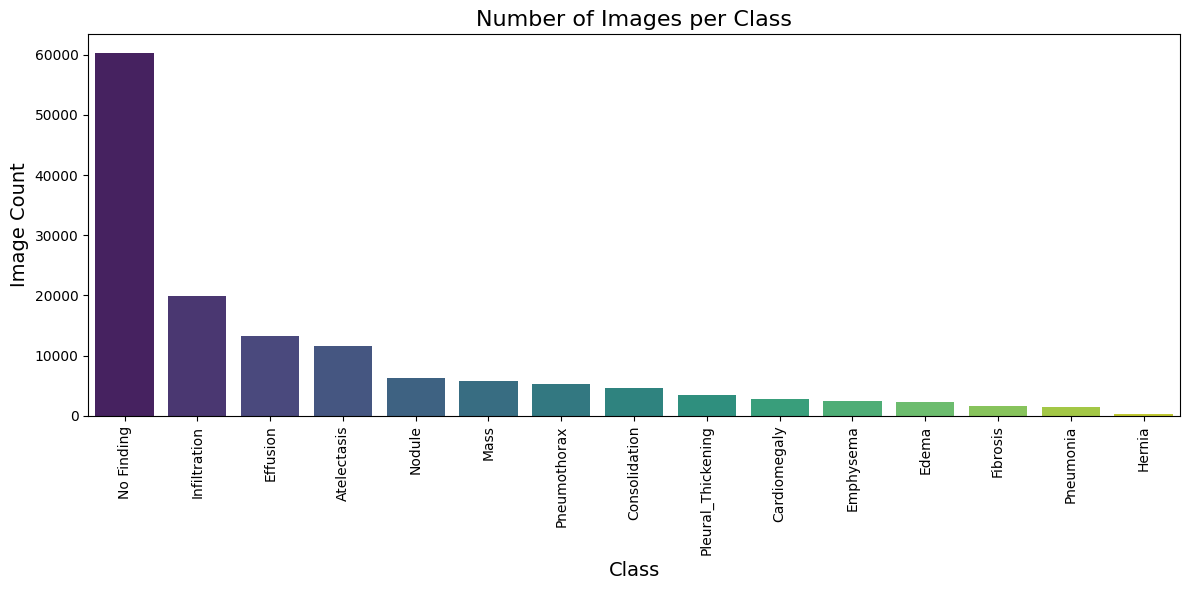

In [9]:
# Path to your class folders
output_dir = "class_folders"

# Collect counts
class_counts = []
for class_name in os.listdir(output_dir):
    class_path = os.path.join(output_dir, class_name)
    if os.path.isdir(class_path):
        count = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
        class_counts.append({"Class": class_name, "Image_Count": count})

# Convert to DataFrame
df_counts = pd.DataFrame(class_counts)

# Sort by count for better visualization
df_counts = df_counts.sort_values(by="Image_Count", ascending=False)

# Plot using seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x="Class", y="Image_Count", data=df_counts, palette="viridis")
plt.xticks(rotation=90)
plt.title("Number of Images per Class", fontsize=16)
plt.xlabel("Class", fontsize=14)
plt.ylabel("Image Count", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
df_counts

,Class,Image_Count
10,No Finding,60361
8,Infiltration,19894
4,Effusion,13317
0,Atelectasis,11559
11,Nodule,6331
9,Mass,5782
14,Pneumothorax,5302
2,Consolidation,4667
12,Pleural_Thickening,3385
1,Cardiomegaly,2776


In [4]:
import os
import random
import shutil
import pandas as pd

In [5]:
def select_and_copy_images(src_root, dest_root, csv_file, n=1000):
    """
    Select random N images from each folder in src_root, copy to dest_root, 
    and save their paths and labels into a CSV file.
    
    Args:
        src_root (str): Source folder containing class folders.
        dest_root (str): Destination root folder where sampled images will be copied.
        csv_file (str): Path to save CSV file.
        n (int): Number of images to select per class.
    """
    data = []

    # Ensure destination root exists
    os.makedirs(dest_root, exist_ok=True)

    # Loop through each class folder
    for class_name in os.listdir(src_root):
        class_path = os.path.join(src_root, class_name)
        if not os.path.isdir(class_path):
            continue

        # Get all images in this class
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if not images:
            continue

        # Randomly select N images (or all if fewer)
        selected_images = random.sample(images, min(n, len(images)))

        # Destination class folder
        dest_class_path = os.path.join(dest_root, class_name)
        os.makedirs(dest_class_path, exist_ok=True)

        # Copy and record
        for img in selected_images:
            src_img_path = os.path.join(class_path, img)
            dest_img_path = os.path.join(dest_class_path, img)
            shutil.copy(src_img_path, dest_img_path)
            
            data.append({"image_path": dest_img_path, "class_name": class_name})

    # Save to CSV
    df = pd.DataFrame(data)
    df.to_csv(csv_file, index=False)
    print(f"Done! Copied images saved in '{dest_root}', CSV saved at '{csv_file}'")


src_root = r"class_folders\seendata"           # your original dataset path
dest_root = r"set"               # destination path
csv_file = r"selected_images.csv"  # CSV output
select_and_copy_images(src_root, dest_root, csv_file, n=2000)


Done! Copied images saved in 'set', CSV saved at 'selected_images.csv'


In [6]:
src_root = r"class_folders\unseendata"           # your original dataset path
dest_root = r"set_unseen"               # destination path
csv_file = r"selected_images_unseen.csv"  # CSV output
select_and_copy_images(src_root, dest_root, csv_file, n=1000)

Done! Copied images saved in 'set_unseen', CSV saved at 'selected_images_unseen.csv'
